# CE444: Geotechnical Design, Homework Assignment 6
Completed by Brandon Auyeung to Dr. Arash Khosravifar. Due on 13th of Febuary, 2026

## Problem 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import great_tables as gt
from icecream import ic
import pandas as pd

In [6]:
p1data = pd.read_excel('ce444w26hw6\CE444_W26_HW6.xlsx', sheet_name = 'CPT', skiprows=2, header=None)
p1data = p1data.drop(p1data.columns[4:], axis=1)
p1data.columns = ["z [ft]", "qc [tsf]", "fs [tsf]", "u2 [tsf]"]
p1data

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\bahea\AppData\Local\Temp\ipykernel_3884\980139612.py:1: SyntaxWarning: invalid escape sequence '\C'
  p1data = pd.read_excel('ce444w26hw6\CE444_W26_HW6.xlsx', sheet_name = 'CPT', skiprows=2, header=None)


,z [ft],qc [tsf],fs [tsf],u2 [tsf]
0,0.250,25.077,0.054,0
1,0.750,41.810,0.410,0
2,1.250,58.716,1.338,0
3,1.750,32.454,1.248,0
4,2.250,33.036,1.484,0
...,...,...,...,...
192,96.249,71.581,3.845,0
193,96.749,91.222,4.056,0
194,97.249,103.905,4.307,0
195,97.749,80.735,4.044,0


1 tsf = 95.76 kPa

In [7]:
# convert to SI from Imperial
p1data['z [m]'] = p1data['z [ft]'] / 3.281 #  3.281 ft = 1 m
p1data['qc [kPa]'] = p1data['qc [tsf]'] * 95.76  # 1 tsf = 95.76 kPa
p1data['fs [kPa]'] = p1data['fs [tsf]'] * 95.76  # 1 tsf = 95.76 kPa
p1data['u2 [kPa]'] = p1data['u2 [tsf]'] * 95.76  # 1 tsf = 95.76 kPa
p1data

,z [ft],qc [tsf],fs [tsf],u2 [tsf],z [m],qc [kPa],fs [kPa],u2 [kPa]
0,0.250,25.077,0.054,0,0.076196,2401.37352,5.17104,0.0
1,0.750,41.810,0.410,0,0.228589,4003.72560,39.26160,0.0
2,1.250,58.716,1.338,0,0.380981,5622.64416,128.12688,0.0
3,1.750,32.454,1.248,0,0.533374,3107.79504,119.50848,0.0
4,2.250,33.036,1.484,0,0.685767,3163.52736,142.10784,0.0
...,...,...,...,...,...,...,...,...
192,96.249,71.581,3.845,0,29.335264,6854.59656,368.19720,0.0
193,96.749,91.222,4.056,0,29.487656,8735.41872,388.40256,0.0
194,97.249,103.905,4.307,0,29.640049,9949.94280,412.43832,0.0
195,97.749,80.735,4.044,0,29.792441,7731.18360,387.25344,0.0


In [ ]:
# assumptions 
gamma = 17 # kN/m^3
gamma_w = 9.81 # kN/m^3
# gwt at surf.
# assume tip correction factor is already applied 

p1data['pwp [kPa]'] = p1data['z [m]']*gamma_w
p1data['tvStress [kPa]'] = p1data['z [m]']*gamma
p1data['veStress [kPa]'] = p1data['tvStress [kPa]'] -  p1data['pwp [kPa]']
p1data

,z [ft],qc [tsf],fs [tsf],u2 [tsf],z [m],qc [kPa],fs [kPa],u2 [kPa],pwp [kPa],tvStress [kPa],veStress [kPa]
0,0.250,25.077,0.054,0,0.076196,2401.37352,5.17104,0.0,0.747486,1.295337,0.547851
1,0.750,41.810,0.410,0,0.228589,4003.72560,39.26160,0.0,2.242457,3.886010,1.643554
2,1.250,58.716,1.338,0,0.380981,5622.64416,128.12688,0.0,3.737428,6.476684,2.739256
3,1.750,32.454,1.248,0,0.533374,3107.79504,119.50848,0.0,5.232399,9.067358,3.834959
4,2.250,33.036,1.484,0,0.685767,3163.52736,142.10784,0.0,6.727370,11.658031,4.930661
...,...,...,...,...,...,...,...,...,...,...,...
192,96.249,71.581,3.845,0,29.335264,6854.59656,368.19720,0.0,287.778936,498.699482,210.920546
193,96.749,91.222,4.056,0,29.487656,8735.41872,388.40256,0.0,289.273907,501.290155,212.016248
194,97.249,103.905,4.307,0,29.640049,9949.94280,412.43832,0.0,290.768878,503.880829,213.111951
195,97.749,80.735,4.044,0,29.792441,7731.18360,387.25344,0.0,292.263849,506.471503,214.207653


In [9]:
# calculate I_c

p1data['qt [kPa]'] = p1data['qc [kPa]']
# note: qt calc is practically negligible since differnce between qt and qc is minimal. 
# calc is being done for completeness, rather than necesity
p1data['Qt'] = (p1data['qt [kPa]'] - p1data['tvStress [kPa]'])/p1data['veStress [kPa]']
p1data['Fr [%]'] = (100) * (p1data['fs [kPa]']/(p1data['qt [kPa]'] - p1data['tvStress [kPa]']))

p1data['Ic'] = np.sqrt((3.47 - np.log10(p1data['Qt']))**2 + (np.log10(p1data['Fr [%]']) + 1.22)**2)# values appear to be too high... need to check 

p1data['Soil Behavior'] = np.zeros(len(p1data['Ic']))

for i, rad in enumerate(p1data['Ic']):
    if rad < 2.6:
        p1data.loc[i, 'Soil Behavior'] = 0 # sand
    else:
        p1data.loc[i, 'Soil Behavior'] = 1 # clay

p1data

,z [ft],qc [tsf],fs [tsf],u2 [tsf],z [m],qc [kPa],fs [kPa],u2 [kPa],pwp [kPa],tvStress [kPa],veStress [kPa],qt [kPa],Qt,Fr [%],Ic,Soil Behavior
0,0.250,25.077,0.054,0,0.076196,2401.37352,5.17104,0.0,0.747486,1.295337,0.547851,2401.37352,4380.893752,0.215453,0.579338,0.0
1,0.750,41.810,0.410,0,0.228589,4003.72560,39.26160,0.0,2.242457,3.886010,1.643554,4003.72560,2433.652980,0.981579,1.214815,0.0
2,1.250,58.716,1.338,0,0.380981,5622.64416,128.12688,0.0,3.737428,6.476684,2.739256,5622.64416,2050.252627,2.281394,1.586109,0.0
3,1.750,32.454,1.248,0,0.533374,3107.79504,119.50848,0.0,5.232399,9.067358,3.834959,3107.79504,808.021103,3.856695,1.891800,0.0
4,2.250,33.036,1.484,0,0.685767,3163.52736,142.10784,0.0,6.727370,11.658031,4.930661,3163.52736,639.238650,4.508684,1.988317,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,96.249,71.581,3.845,0,29.335264,6854.59656,368.19720,0.0,287.778936,498.699482,210.920546,6854.59656,30.134082,5.793001,2.809939,1.0
193,96.749,91.222,4.056,0,29.487656,8735.41872,388.40256,0.0,289.273907,501.290155,212.016248,8735.41872,38.837253,4.716984,2.668931,1.0
194,97.249,103.905,4.307,0,29.640049,9949.94280,412.43832,0.0,290.768878,503.880829,213.111951,9949.94280,44.324412,4.366246,2.604733,1.0
195,97.749,80.735,4.044,0,29.792441,7731.18360,387.25344,0.0,292.263849,506.471503,214.207653,7731.18360,33.727610,5.360123,2.751491,1.0


In [11]:
Nk = 18 # dim.less factor
const_NC = 0.22 # (Su/veStress)_NC = 0.22
Pa = 100 # kPa
p1data['DR [%]'] = np.zeros(len(p1data['Ic']))
p1data['phi [deg]'] = np.zeros(len(p1data['Ic']))
p1data['Su [kPa]'] = np.zeros(len(p1data['Ic']))
p1data['OCR'] = np.zeros(len(p1data['Ic']))

for i, flag in enumerate(p1data['Soil Behavior']):
    if flag == 1: # if clay behavior
        p1data.loc[i, 'DR [%]'] = float('NaN')
        p1data.loc[i, 'phi [deg]'] = float('NaN')
        p1data.loc[i, 'Su [kPa]'] = (p1data['qc [kPa]'][i] - p1data['tvStress [kPa]'][i])/(Nk)
        p1data.loc[i, 'OCR'] = ((p1data['Su [kPa]'][i]/p1data['veStress [kPa]'][i])/const_NC)**(1/0.8)

    if flag == 0: # if sand behavior
        p1data.loc[i, 'DR [%]'] = 68*(np.log10((p1data['qc [kPa]'][i])/(np.sqrt(Pa*p1data['veStress [kPa]'][i])))-1)
        p1data.loc[i, 'phi [deg]'] = np.degrees(np.arctan((2.68**(-1)) * (np.log10(p1data['qc [kPa]'][i]/p1data['veStress [kPa]'][i]) +0.29)))
        p1data.loc[i, 'Su [kPa]'] = float('NaN')
        p1data.loc[i, 'OCR'] = float('NaN')

p1data

,z [ft],qc [tsf],fs [tsf],u2 [tsf],z [m],qc [kPa],fs [kPa],u2 [kPa],pwp [kPa],tvStress [kPa],veStress [kPa],qt [kPa],Qt,Fr [%],Ic,Soil Behavior,DR [%],phi [deg],Su [kPa],OCR
0,0.250,25.077,0.054,0,0.076196,2401.37352,5.17104,0.0,0.747486,1.295337,0.547851,2401.37352,4380.893752,0.215453,0.579338,0.0,102.756730,55.720791,NaN,NaN
1,0.750,41.810,0.410,0,0.228589,4003.72560,39.26160,0.0,2.242457,3.886010,1.643554,4003.72560,2433.652980,0.981579,1.214815,0.0,101.630919,53.911004,NaN,NaN
2,1.250,58.716,1.338,0,0.380981,5622.64416,128.12688,0.0,3.737428,6.476684,2.739256,5622.64416,2050.252627,2.281394,1.586109,0.0,104.116450,53.351951,NaN,NaN
3,1.750,32.454,1.248,0,0.533374,3107.79504,119.50848,0.0,5.232399,9.067358,3.834959,3107.79504,808.021103,3.856695,1.891800,0.0,81.638897,50.042292,NaN,NaN
4,2.250,33.036,1.484,0,0.685767,3163.52736,142.10784,0.0,6.727370,11.658031,4.930661,3163.52736,639.238650,4.508684,1.988317,0.0,78.452892,49.131048,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,96.249,71.581,3.845,0,29.335264,6854.59656,368.19720,0.0,287.778936,498.699482,210.920546,6854.59656,30.134082,5.793001,2.809939,1.0,NaN,NaN,353.105393,12.638731
193,96.749,91.222,4.056,0,29.487656,8735.41872,388.40256,0.0,289.273907,501.290155,212.016248,8735.41872,38.837253,4.716984,2.668931,1.0,NaN,NaN,457.451587,17.355680
194,97.249,103.905,4.307,0,29.640049,9949.94280,412.43832,0.0,290.768878,503.880829,213.111951,9949.94280,44.324412,4.366246,2.604733,1.0,NaN,NaN,524.781221,20.473154
195,97.749,80.735,4.044,0,29.792441,7731.18360,387.25344,0.0,292.263849,506.471503,214.207653,7731.18360,33.727610,5.360123,2.751491,1.0,NaN,NaN,401.372894,14.549999


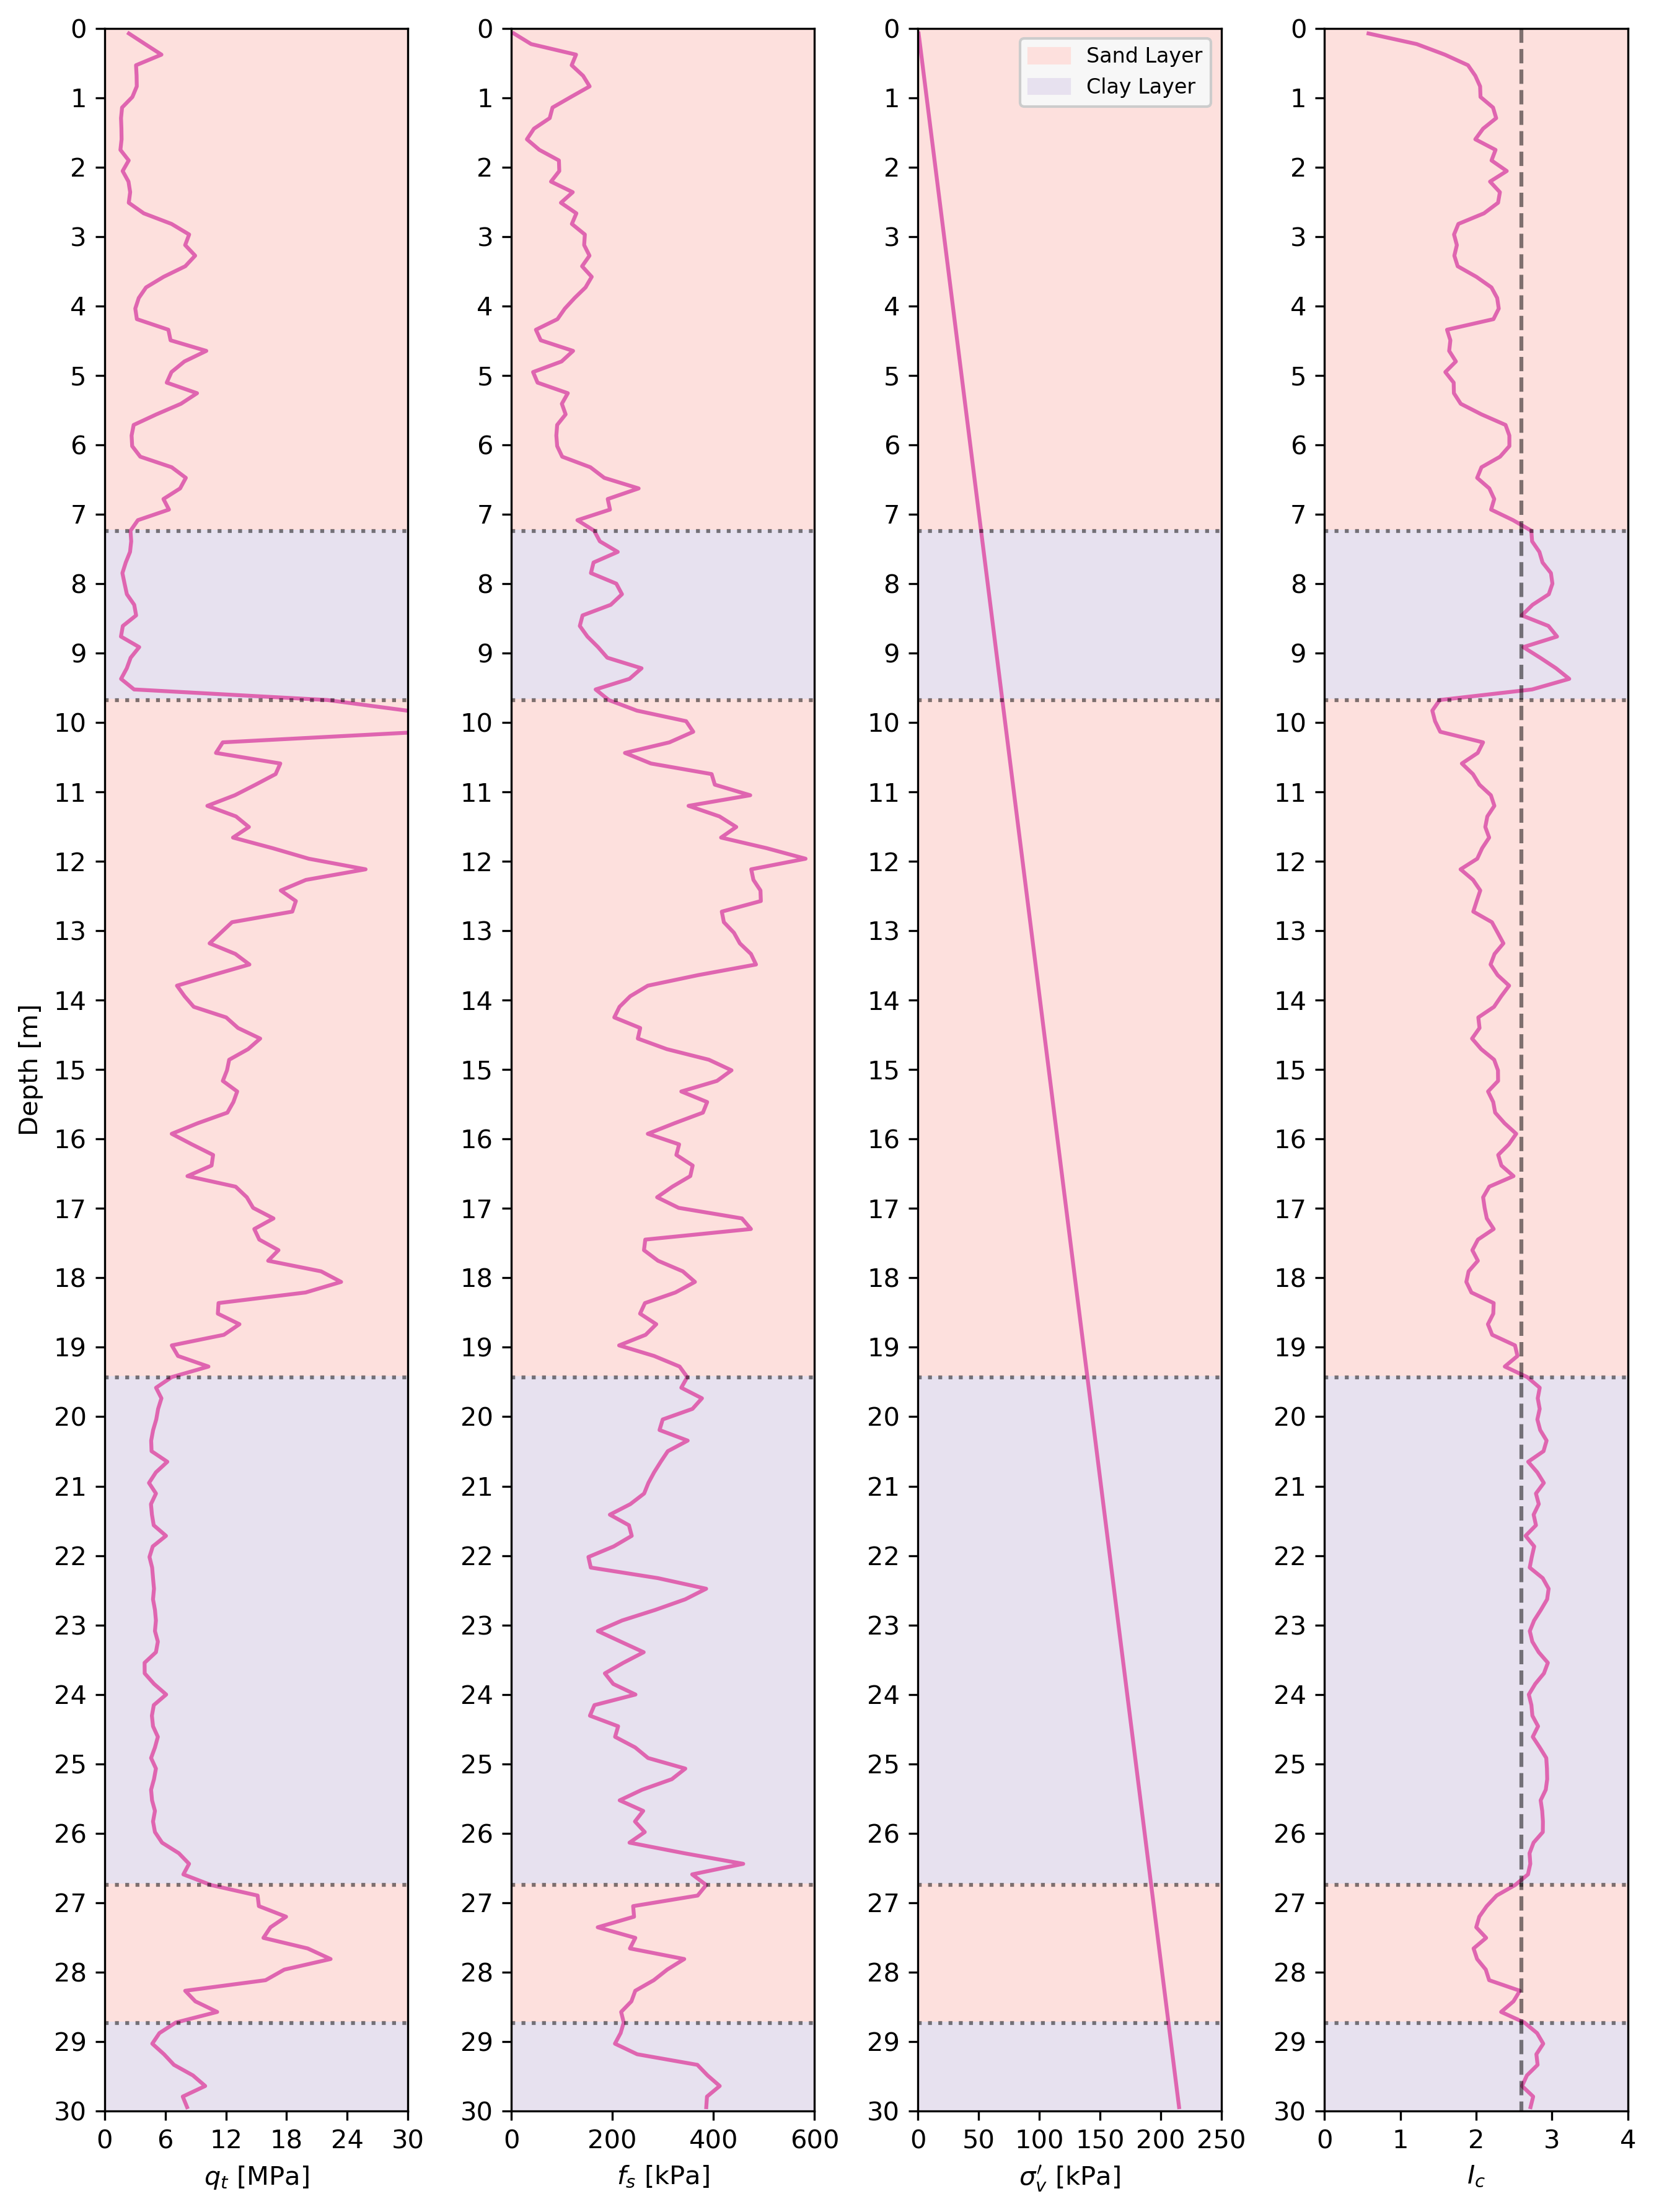

In [ ]:
# plot values: qt, fs, veStress, Ic

fig, ax = plt.subplots(1,4, figsize=(9,12), tight_layout=True, dpi=300)
ax[0].plot(p1data['qt [kPa]']/1000, p1data['z [m]'], color = "#df65b0", marker='None', linestyle='-')
ax[1].plot(p1data['fs [kPa]'], p1data['z [m]'], color = "#df65b0", marker='None', linestyle='-')
ax[2].plot(p1data['veStress [kPa]'], p1data['z [m]'], color = "#df65b0", marker='None', linestyle='-')
ax[3].plot(p1data['Ic'], p1data['z [m]'], color = "#df65b0", marker='None', linestyle='-')

# ax[0].vlines(5, 0, 30, color = 'black', alpha =0.5, linestyles = 'dashed')
ax[3].vlines(2.6, 0, 30, color = 'black', alpha =0.5, linestyles = 'dashed')

    layer1_end = 7.24
    layer2_end = 9.68
    layer3_end = 19.43
    layer4_end = 26.74
    layer5_end = 28.73

for i in range(4):
    ax[i].set_ylim(0,30)
    ax[i].set_yticks(np.arange(0,31,1))
    ax[i].invert_yaxis()
    ax[i].hlines(layer1_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].hlines(layer2_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].hlines(layer3_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].hlines(layer4_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].hlines(layer5_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].fill_betweenx([0, layer1_end], 0, 1000, color = '#fde0dd', label = 'Sand Layer')
    ax[i].fill_betweenx([layer1_end, layer2_end], 0, 1000, color = '#e7e1ef', label = 'Clay Layer')
    ax[i].fill_betweenx([layer2_end, layer3_end], 0, 1000, color = '#fde0dd')
    ax[i].fill_betweenx([layer3_end, layer4_end], 0, 1000, color = '#e7e1ef')
    ax[i].fill_betweenx([layer4_end, layer5_end], 0, 1000, color = '#fde0dd')
    ax[i].fill_betweenx([layer5_end, 30], 0, 1000, color = '#e7e1ef')

ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$q_t$ [MPa]')
ax[1].set_xlabel('$f_s$ [kPa]')
ax[2].set_xlabel("$\\sigma_v'$ [kPa]")
ax[3].set_xlabel('$I_c$')

ax[2].legend(frameon=True, loc='upper right', fontsize=8, framealpha=1, facecolor = '#f7f7f7')

ax[0].set_xlim(0, 30)
ax[0].set_xticks(np.linspace(0, 30, 6))
ax[1].set_xlim(0, 600)
ax[1].set_xticks(np.linspace(0, 600, 4))
ax[2].set_xlim(0, 250)
ax[2].set_xticks(np.linspace(0, 250, 6))
ax[3].set_xlim(0, 4)
ax[3].set_xticks([0, 1, 2, 3, 4])

plt.show()

Provide BE for $D_R$ and $\phi'$ for the sand layers. Provide BE for $S_u$ and $OCR$ for the clay layer.

In [48]:
sand_layer_1 = p1data.loc[(p1data['z [m]'] < layer1_end), ('phi [deg]', 'DR [%]')]
sand_layer_2 = p1data.loc[(layer2_end < p1data['z [m]']) & (p1data['z [m]'] < layer3_end), ('phi [deg]', 'DR [%]')]
sand_layer_3 = p1data.loc[(layer4_end < p1data['z [m]']) & (p1data['z [m]'] < layer5_end), ('phi [deg]', 'DR [%]')]

print('Sand Layer 1')
print(np.nanmean(sand_layer_1['phi [deg]']), np.nanstd(sand_layer_1['phi [deg]']))
print(np.nanmean(sand_layer_1['DR [%]']), np.nanstd(sand_layer_1['DR [%]']))

print('Sand Layer 2')
print(np.nanmean(sand_layer_2['phi [deg]']), np.nanstd(sand_layer_2['phi [deg]']))
print(np.nanmean(sand_layer_2['DR [%]']), np.nanstd(sand_layer_2['DR [%]']))

print('Sand Layer 3')
print(np.nanmean(sand_layer_3['phi [deg]']), np.nanstd(sand_layer_3['phi [deg]']))
print(np.nanmean(sand_layer_3['DR [%]']), np.nanstd(sand_layer_3['DR [%]']))

Sand Layer 1
44.081763043848724 3.8293786980665643
66.03785095526399 16.420825388245806
Sand Layer 2
41.855579864572505 2.334078221168394
76.43174663459732 11.765167598050805
Sand Layer 3
38.691011494442854 1.7707614888497982
68.60604422061925 8.988884823658356


In [49]:
clay_layer_1 = p1data.loc[(layer1_end < p1data['z [m]']) & (p1data['z [m]'] < layer2_end), ('Su [kPa]', 'OCR')]
clay_layer_2 = p1data.loc[(layer3_end < p1data['z [m]']) & (p1data['z [m]'] < layer4_end), ('Su [kPa]', 'OCR')]
clay_layer_3 = p1data.loc[(layer5_end < p1data['z [m]']), ('Su [kPa]', 'OCR')]

print('Clay Layer 1')
print(np.nanmean(clay_layer_1['Su [kPa]']), np.nanstd(clay_layer_1['Su [kPa]']))
print(np.nanmean(clay_layer_1['OCR']), np.nanstd(clay_layer_1['OCR']))

print('Clay Layer 2')
print(np.nanmean(clay_layer_2['Su [kPa]']), np.nanstd(clay_layer_2['Su [kPa]']))
print(np.nanmean(clay_layer_2['OCR']), np.nanstd(clay_layer_2['OCR']))

print('Clay Layer 3')
print(np.nanmean(clay_layer_3['Su [kPa]']), np.nanstd(clay_layer_3['Su [kPa]']))
print(np.nanmean(clay_layer_3['OCR']), np.nanstd(clay_layer_3['OCR']))

Clay Layer 1
122.9582151433506 30.431617765585166
16.266043154564787 5.015956602428774
Clay Layer 2
263.1398587371232 46.004158143918644
11.921134053649471 2.5153270342857765
Clay Layer 3
371.0935000748417 92.57028507249657
13.490453913975262 4.037250293890492


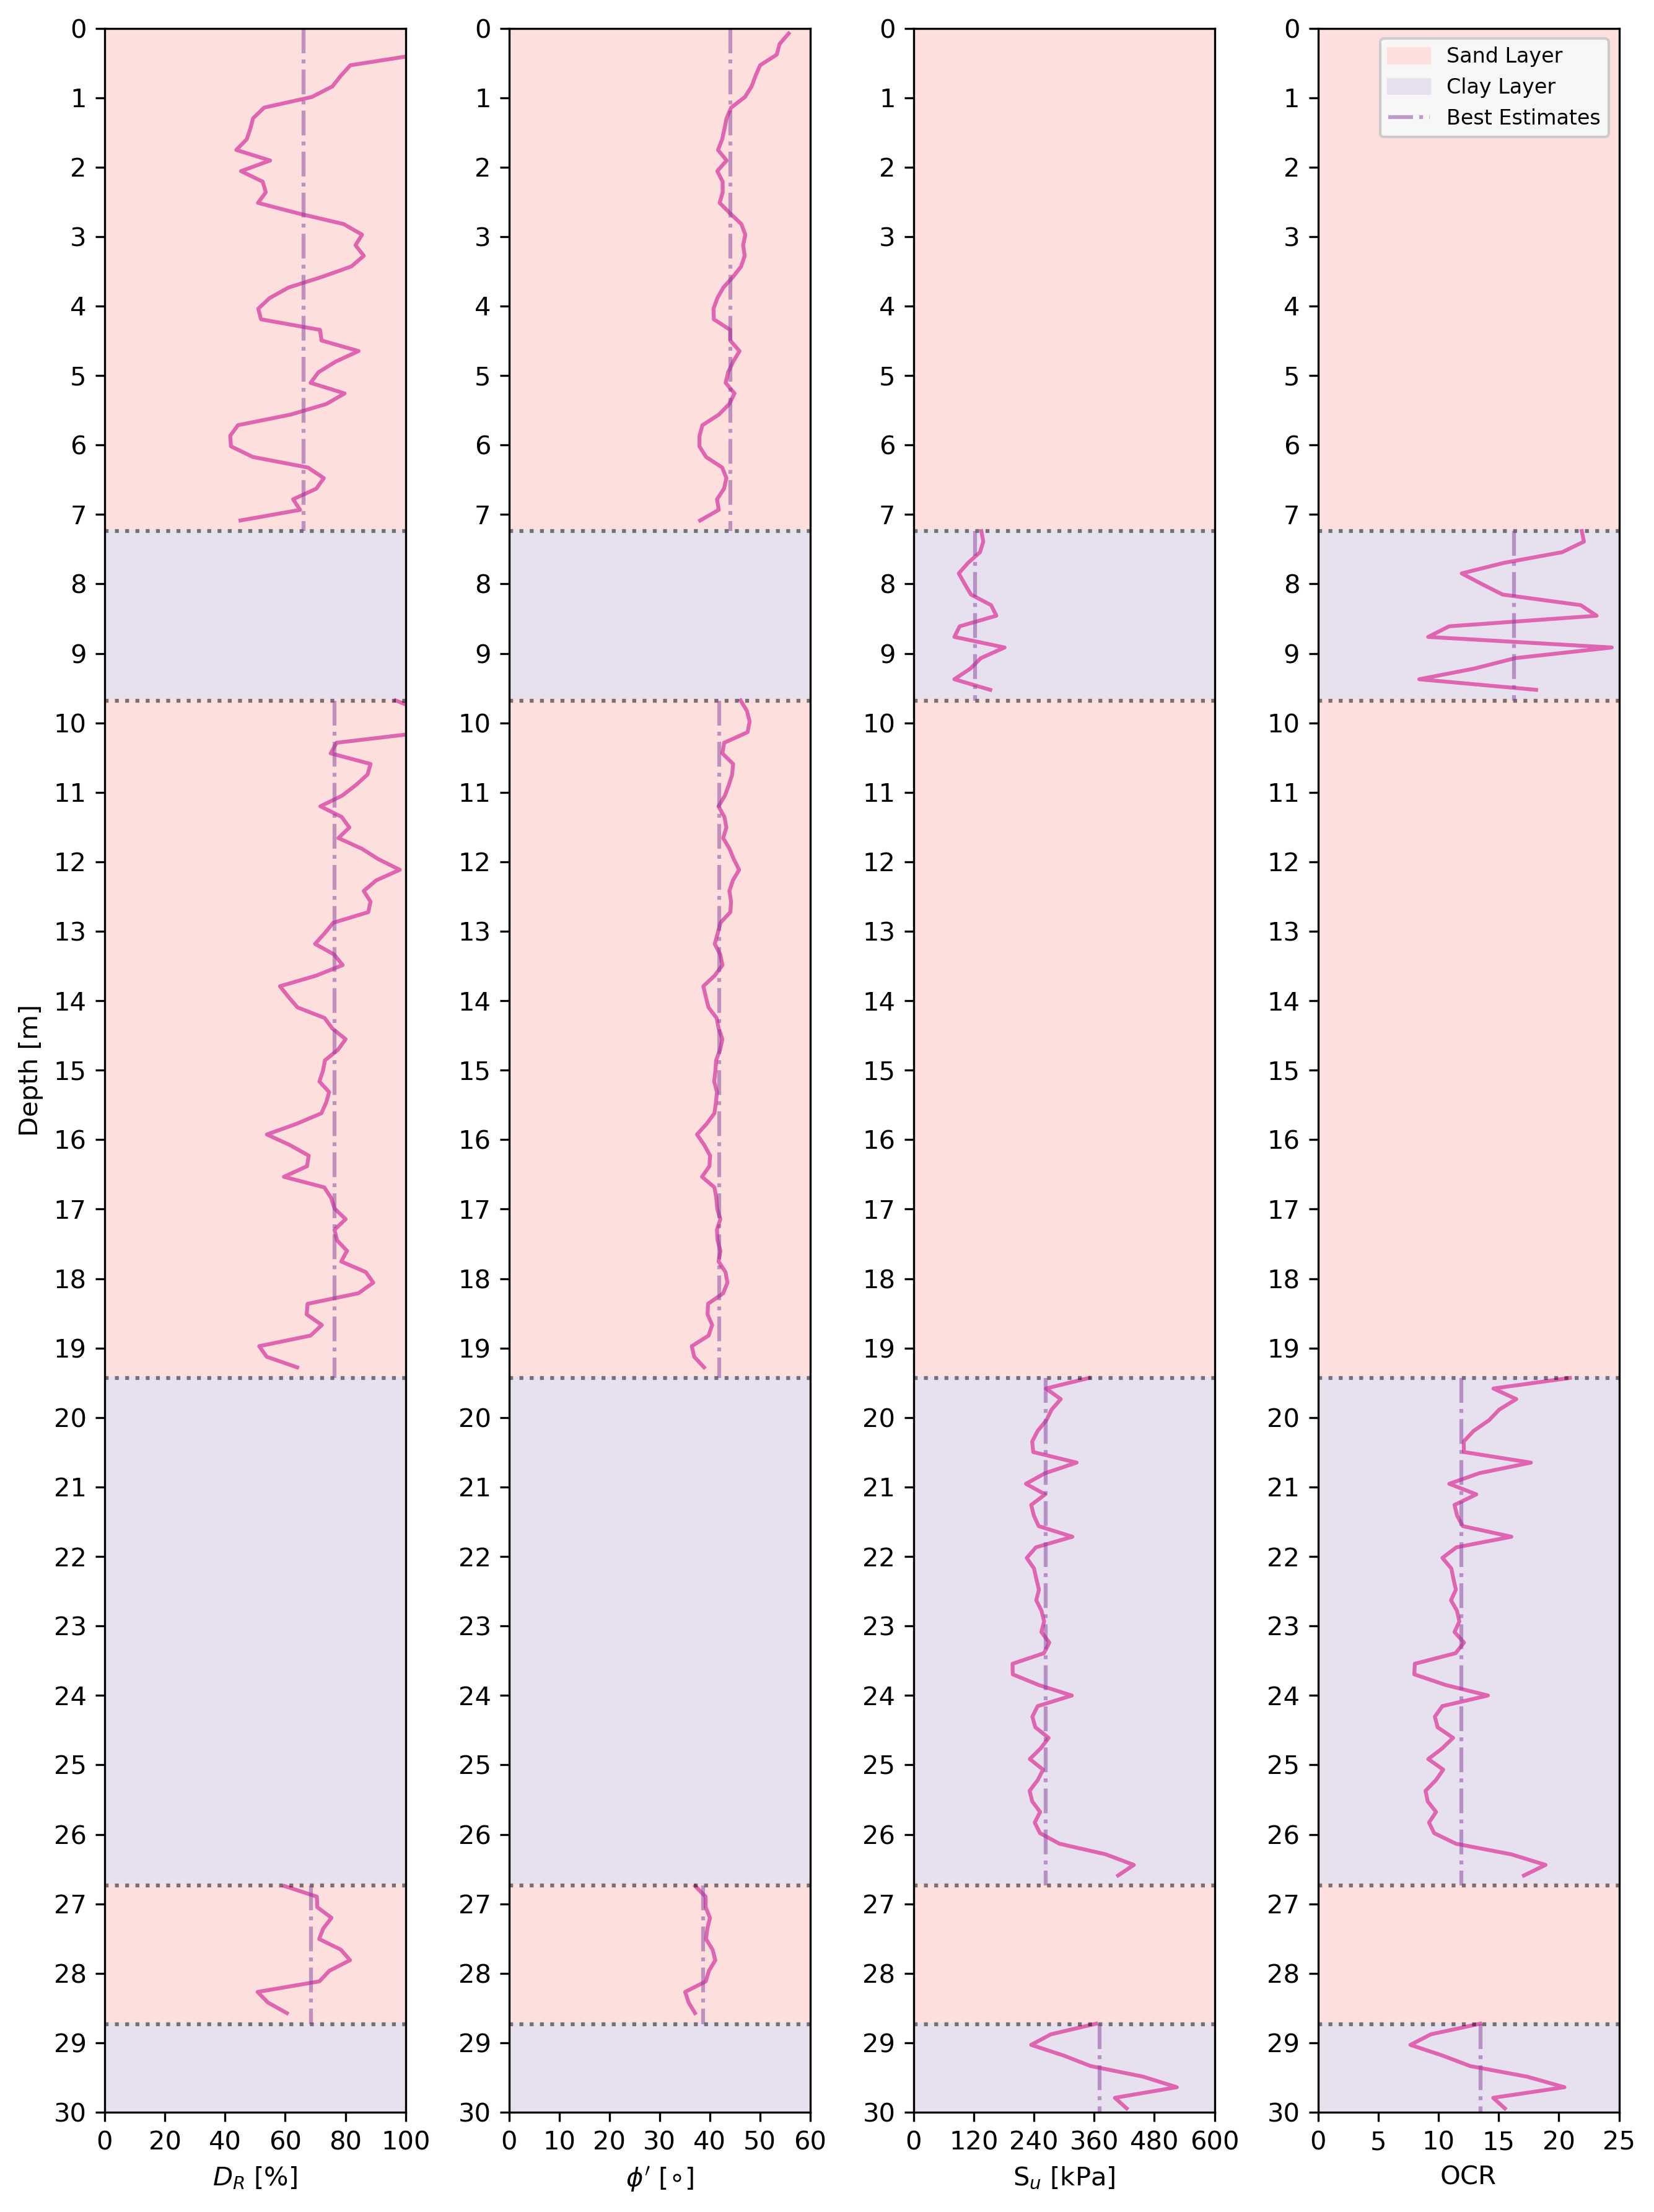

In [55]:
# plot values: DR, phi, Su, OCR

fig, ax = plt.subplots(1,4, figsize=(9,12), tight_layout=True, dpi=300)
ax[0].plot(p1data['DR [%]'], p1data['z [m]'], color = "#df65b0", marker='None', linestyle='-')
ax[1].plot(p1data['phi [deg]'], p1data['z [m]'], color = "#df65b0", marker='None', linestyle='-')
ax[2].plot(p1data['Su [kPa]'], p1data['z [m]'], color = "#df65b0", marker='None', linestyle='-')
ax[3].plot(p1data['OCR'], p1data['z [m]'], color = "#df65b0", marker='None', linestyle='-')

for i in range(4):
    ax[i].set_ylim(0,30)
    ax[i].set_yticks(np.arange(0,31,1))
    ax[i].invert_yaxis()
    ax[i].hlines(layer1_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].hlines(layer2_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].hlines(layer3_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].hlines(layer4_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].hlines(layer5_end, 0, 1000, color = 'black', alpha =0.5, linestyles = ':')
    ax[i].fill_betweenx([0, layer1_end], 0, 1000, color = '#fde0dd', label = 'Sand Layer')
    ax[i].fill_betweenx([layer1_end, layer2_end], 0, 1000, color = '#e7e1ef', label = 'Clay Layer')
    ax[i].fill_betweenx([layer2_end, layer3_end], 0, 1000, color = '#fde0dd')
    ax[i].fill_betweenx([layer3_end, layer4_end], 0, 1000, color = '#e7e1ef')
    ax[i].fill_betweenx([layer4_end, layer5_end], 0, 1000, color = '#fde0dd')
    ax[i].fill_betweenx([layer5_end, 30], 0, 1000, color = '#e7e1ef')

ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$D_R$ [%]')
ax[1].set_xlabel("$\\phi'$ [$\\circ$]")
ax[2].set_xlabel("S$_u$ [kPa]")
ax[3].set_xlabel('OCR')

ax[0].vlines(np.nanmean(sand_layer_1['DR [%]']), 0, layer1_end, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[0].vlines(np.nanmean(sand_layer_2['DR [%]']), layer2_end, layer3_end, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[0].vlines(np.nanmean(sand_layer_3['DR [%]']), layer4_end, layer5_end, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[1].vlines(np.nanmean(sand_layer_1['phi [deg]']), 0, layer1_end, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[1].vlines(np.nanmean(sand_layer_2['phi [deg]']), layer2_end, layer3_end, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[1].vlines(np.nanmean(sand_layer_3['phi [deg]']), layer4_end, layer5_end, color = '#88419d', alpha =0.5, linestyles = '-.')

ax[2].vlines(np.nanmean(clay_layer_1['Su [kPa]']), layer1_end, layer2_end, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[2].vlines(np.nanmean(clay_layer_2['Su [kPa]']), layer3_end, layer4_end, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[2].vlines(np.nanmean(clay_layer_3['Su [kPa]']), layer5_end, 30, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[3].vlines(np.nanmean(clay_layer_1['OCR']), layer1_end, layer2_end, color = '#88419d', alpha =0.5, linestyles = '-.', label = "Best Estimates")
ax[3].vlines(np.nanmean(clay_layer_2['OCR']), layer3_end, layer4_end, color = '#88419d', alpha =0.5, linestyles = '-.')
ax[3].vlines(np.nanmean(clay_layer_3['OCR']), layer5_end, 30, color = '#88419d', alpha =0.5, linestyles = '-.')


ax[3].legend(frameon=True, loc='upper right', fontsize=8, framealpha=1, facecolor = '#f7f7f7')

ax[0].set_xlim(0, 100)
ax[0].set_xticks(np.arange(0,101,20))
ax[1].set_xlim(0, 60)
ax[1].set_xticks([0, 10, 20, 30, 40, 50, 60])
ax[2].set_xlim(0, 600)
ax[2].set_xticks(np.linspace(0, 600, 6))
ax[3].set_xlim(0, 25)
ax[3].set_xticks([0, 5, 10, 15, 20, 25])

plt.show()